<a href="https://colab.research.google.com/github/Girawale-Sanket/Time-Series-Final-Project-/blob/main/Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MICROSOFT CORPORATION (MSFT) Dataset

Step 1: Install Dependencies & Data Collection

Fetch live historical data from Yahoo Finance.

In [16]:
data=yf.download('MSFT',start="2020-01-01", end="2026-09-10")

/tmp/ipykernel_866/3335288389.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('MSFT',start="2020-01-01", end="2026-09-10")
[*********************100%***********************]  1 of 1 completed


In [17]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2020-01-02,151.544281,151.648066,149.383682,149.808252,22622100
2020-01-03,149.657272,150.912123,149.128917,149.374235,21116200
2020-01-06,150.044128,150.110180,147.666515,148.204315,20813700
2020-01-07,148.676041,150.647943,148.430737,150.317728,21634100
2020-01-08,151.044235,151.714124,149.025155,149.949777,27746500


In [18]:
data.shape

(1680, 5)

Step 2: Data Preprocessing & Structuring

Time series models require a continuous index and missing value handling.

In [19]:
data.isnull().sum()

,,0
Price,Ticker,
Close,MSFT,0
High,MSFT,0
Low,MSFT,0
Open,MSFT,0
Volume,MSFT,0


In [20]:
# Flatten MultiIndex columns if yfinance returns nested headers
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

In [21]:
# Select relevant column: 'Close' or 'Adj Close'
ts_data = data[['Close']].copy()

In [22]:
# Ensure Datetime Index frequency (Business Days)
ts_data = ts_data.asfreq('B')

In [23]:
# Handle missing values (e.g., market holidays) via Forward Fill
ts_data['Close'] = ts_data['Close'].ffill().bfill()

In [24]:
# Verify null values
print("Missing values count after imputation:")
print(ts_data.isnull().sum())

Missing values count after imputation:
Price
Close    0
dtype: int64


Step 3: Exploratory Data Analysis (EDA)

Analyze trends, moving averages, and time series components.

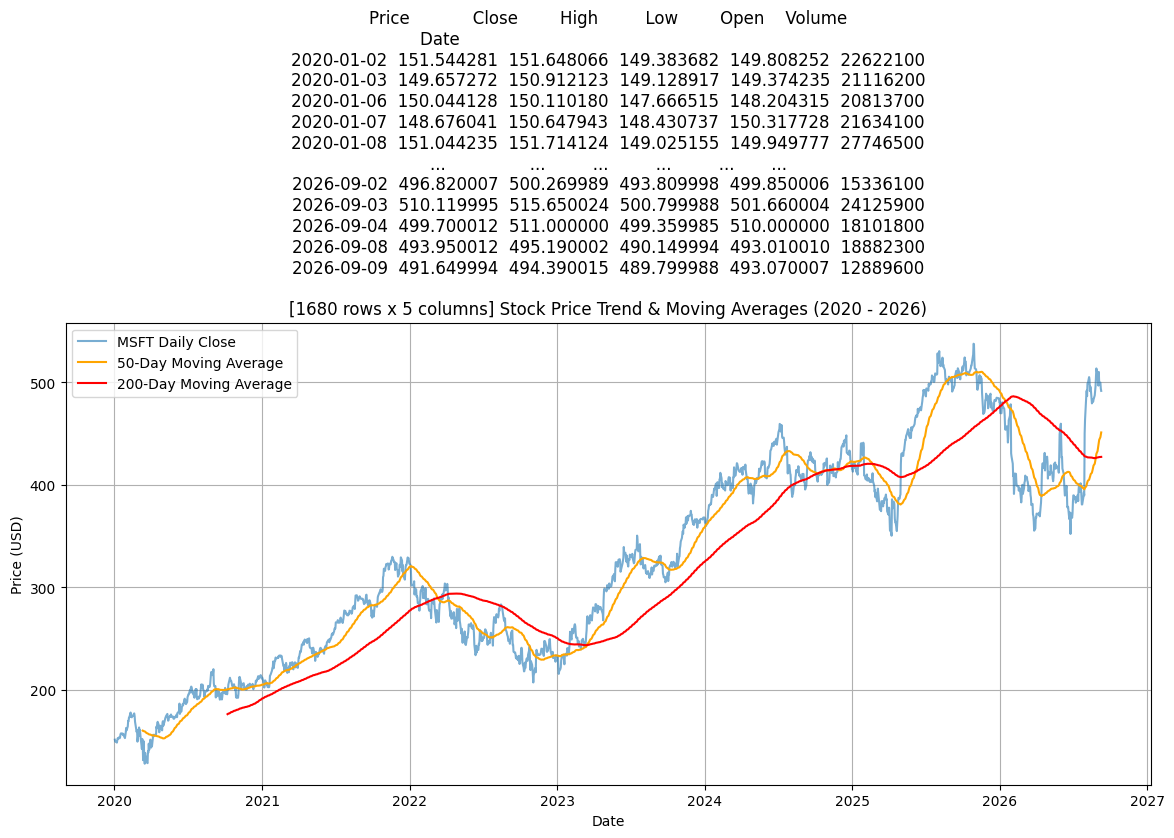

In [25]:
# 1. Historical Closing Price & Moving Averages
ts_data['MA_50'] = ts_data['Close'].rolling(window=50).mean()
ts_data['MA_200'] = ts_data['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(ts_data['Close'], label='MSFT Daily Close', alpha=0.6)
plt.plot(ts_data['MA_50'], label='50-Day Moving Average', color='orange')
plt.plot(ts_data['MA_200'], label='200-Day Moving Average', color='red')
plt.title(f'{data} Stock Price Trend & Moving Averages (2020 - 2026)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

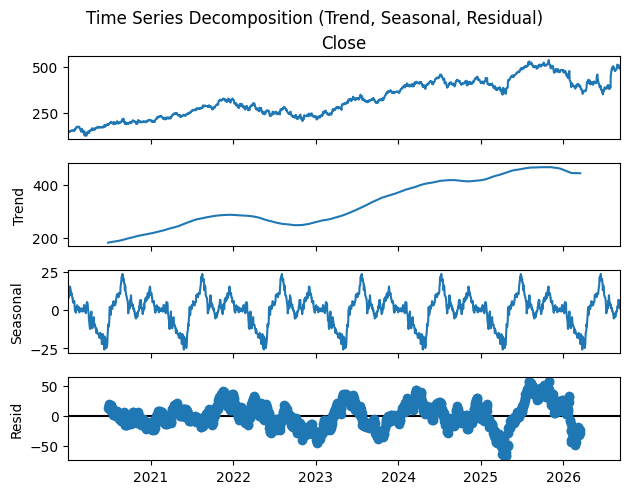

In [26]:
# 2. Time Series Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts_data['Close'], model='additive', period=252)
decomposition.plot()
plt.suptitle('Time Series Decomposition (Trend, Seasonal, Residual)', y=1.02)
plt.show()

Step 4: Stationarity Test & Auto-ARIMA Forecasting

Statistical models like ARIMA require check for stationarity using the Augmented Dickey-Fuller (ADF) test.

In [27]:
!pip install pmdarima

In [28]:
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

In [29]:
# Stationarity Check
result = adfuller(ts_data['Close'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

ADF Statistic: -1.2163
p-value: 0.6665


/tmp/ipykernel_866/1299437644.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(ts_data['Close'])


In [30]:
# Train / Test Split (80% Train, 20% Test)
train_size = int(len(ts_data) * 0.8)
train_data = ts_data['Close'].iloc[:train_size]
test_data = ts_data['Close'].iloc[train_size:]

In [31]:
# Automatically select best ARIMA (p, d, q) parameters
model = auto_arima(train_data, seasonal=False, stepwise=True, trace=True)
print("\nModel Summary:")
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8440.707, Time=1.84 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8441.360, Time=0.13 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8436.457, Time=0.36 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8436.002, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8441.650, Time=0.25 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8436.720, Time=3.28 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=8436.814, Time=1.47 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=8438.685, Time=3.19 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=8436.682, Time=0.41 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 11.797 seconds

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1396
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -4215.001
Date:                Thu, 24 Sep

In [32]:
# Generate Predictions for Test Period
n_periods = len(test_data)
forecast_vals, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

In [33]:
# Build pandas Series for forecasted values
forecast_series = pd.Series(forecast_vals, index=test_data.index)

Step 5: Model Evaluation & Visualization

Evaluate model performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Metrics
mae = mean_absolute_error(test_data, forecast_series)
rmse = np.sqrt(mean_squared_error(test_data, forecast_series))

print(f"Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Model Evaluation Metrics:
Mean Absolute Error (MAE): $54.33
Root Mean Squared Error (RMSE): $63.67


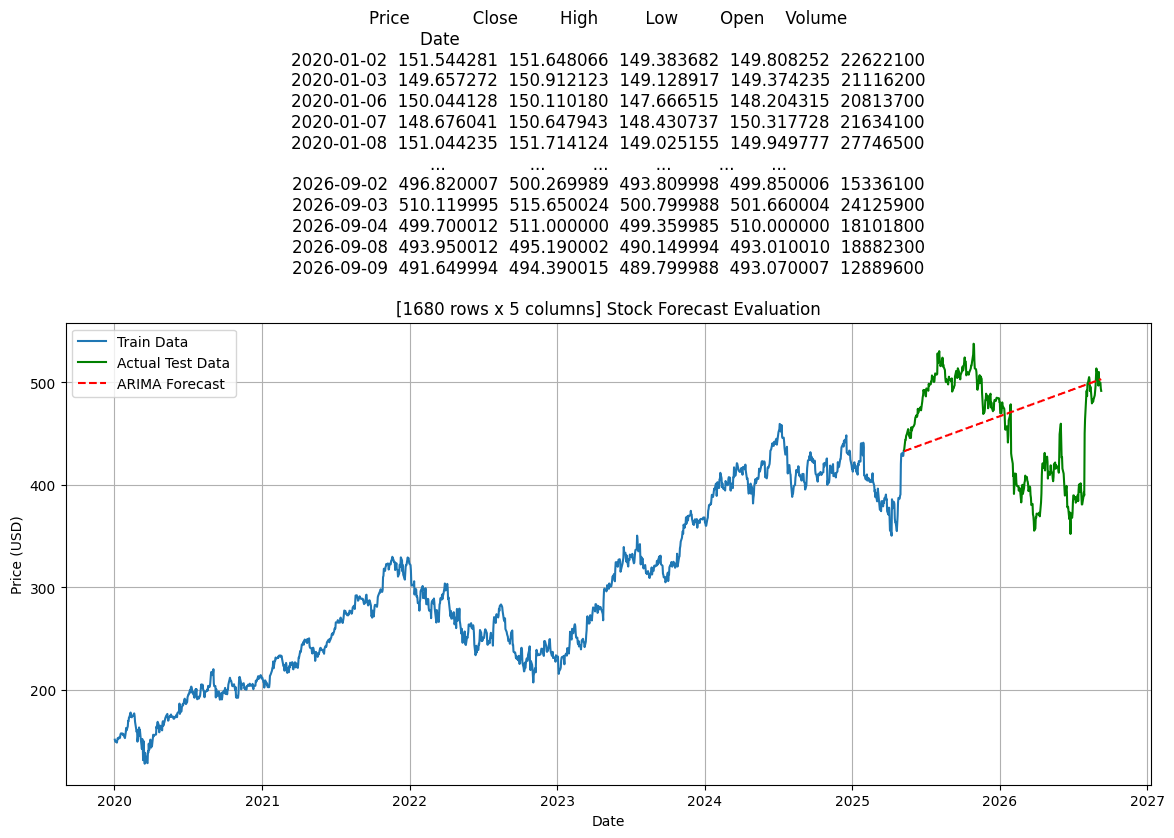

In [35]:
# Plot Forecast vs Actual
plt.figure(figsize=(14, 6))
plt.plot(train_data, label='Train Data')
plt.plot(test_data, label='Actual Test Data', color='green')
plt.plot(forecast_series, label='ARIMA Forecast', color='red', linestyle='--')
plt.title(f'{data} Stock Forecast Evaluation')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()